In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import plotting as pl
from koala.voronization import generate_lattice
from koala.graph_color import color_lattice
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala.lattice import Lattice
from scipy import linalg as la
from pfapack.pfaffian import pfaffian
from copy import copy
from koala.lattice import INVALID
from koala import example_graphs as eg
from dimer_models.koala_plantri import plantri_to_koala, plantri_generator, read_plantri
from dimer_models.lattice_generation import (
    bipartite_squarefull,
    reduce_bipartite,
)
from tqdm import tqdm

import matplotlib as mpl
from collections import Counter

from dimer_models.kasteleyn import find_kasteleyn_number

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


mpl.rcParams.update(
    {
        "font.size": 11,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)

import pickle

In [3]:
from os import listdir
from os.path import isfile, join

mypath = "../monomer_results/expand_edges/"
filenames = sorted([f for f in listdir(mypath) if isfile(join(mypath, f))])

In [4]:
# extract the data

all_results = []

for file in tqdm(filenames):

    with open(mypath + file, "rb") as f:
        res = pickle.load(f)

    for j, r in enumerate(res):

        lat = r["lattice"]
        pairs = r["pairs"]
        partition = r["partition_func"]
        distances = r["distances"]
        mags = r["mags"]
        pows = r["powers"]
        dim_probs = r["dimer_probs"]

        # g_distances = gu.resistance_distance(lat)[pairs[:, 0], pairs[:, 1]]
        probability = (mags / partition[0]) * 10 ** (pows - partition[1])

        dist_unique = np.unique(distances)

        proportion_of_squares = np.array(
            [p.n_sides == 4 for p in lat.plaquettes]
        ).mean()
        # print(proportion_of_squares)

        # mean = np.array([np.mean(probability[distances == x]) for x in dist_unique])
        # upper_quart = np.array(
        #     [np.percentile(probability[distances == x], 25) for x in dist_unique]
        # )
        # lower_quart = np.array(
        #     [np.percentile(probability[distances == x], 75) for x in dist_unique]
        # )
        # upper_lim = np.array([np.max(probability[distances == x]) for x in dist_unique])
        # lower_lim = np.array([np.min(probability[distances == x]) for x in dist_unique])

        all_results.append(
            {
                "lattice": lat,
                "pairs": pairs,
                "partition_func": partition,
                "distances": distances,
                "probability": probability,
                "dim_probs": dim_probs,
                "dist_unique": dist_unique,
                "proportion_of_squares": proportion_of_squares,
                # "mean": mean,
                # "upper_quart": upper_quart,
                # "lower_quart": lower_quart,
                # "upper_lim": upper_lim,
                # "lower_lim": lower_lim,
            }
        )

100%|██████████| 11/11 [00:08<00:00,  1.23it/s]


100%|██████████| 33/33 [00:00<00:00, 956.19it/s]


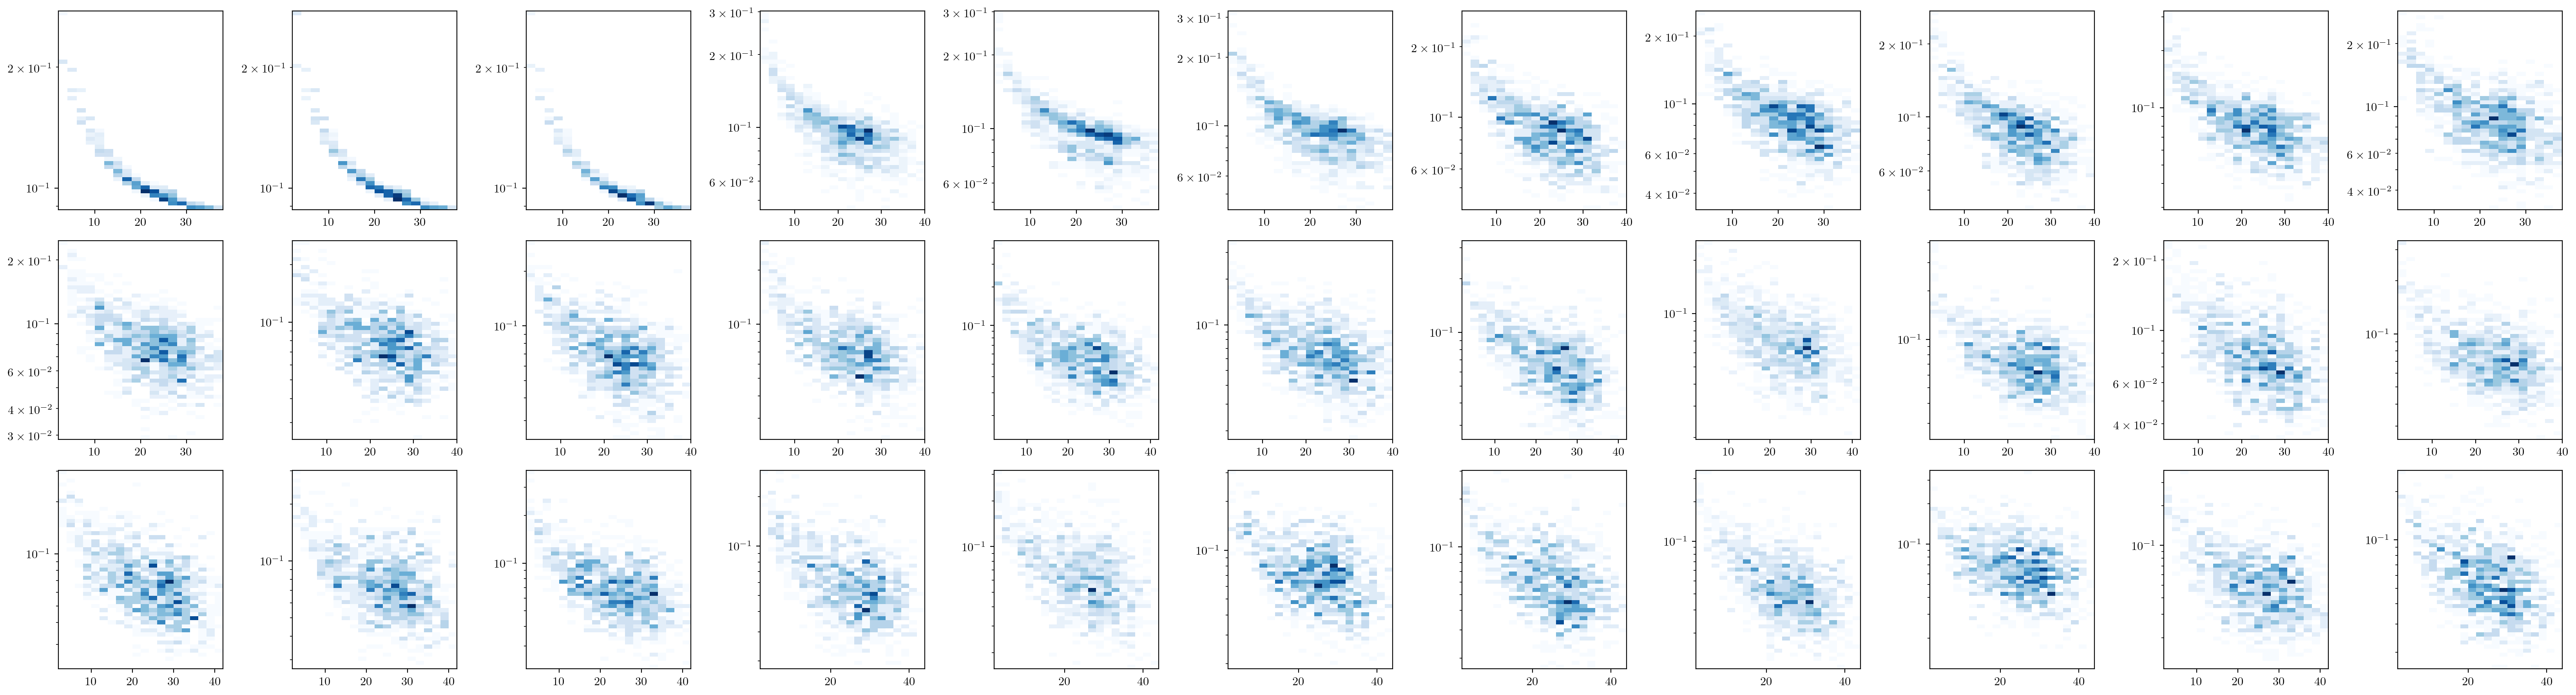

In [10]:
fig, ax = plt.subplots(
    3, len(all_results) // 3, figsize=np.array([len(all_results) // 3, 3]) * 3, dpi=200
)
ax = ax.flatten()

for j, r in enumerate(tqdm(all_results)):

    lat = r["lattice"]
    dist_unique = r["dist_unique"]
    # mean = r["mean"]
    # upper_quart = r["upper_quart"]
    # lower_quart = r["lower_quart"]
    # upper_lim = r["upper_lim"]
    # lower_lim = r["lower_lim"]

    a_plot = ax[j]

    # pl.plot_edges(gu.com_relaxation(lat), ax=ax[0, j])
    # a_plot.scatter(
    #     r["distances"], r["probability"], alpha=0.4, s=0.4, label="data points"
    # )

    x_space = r["dist_unique"]
    y_space = np.logspace(
        np.log10(np.min(r["probability"])),
        np.log10(np.max(r["probability"])),
        num=50,
    )
    x_space = np.arange(np.min(r["distances"]), np.max(r["distances"] + 1))[::2]
    y_space = np.logspace(
        np.log10(np.min(r["probability"])),
        np.log10(np.max(r["probability"])),
        num=50,
    )
    ax[j].hist2d(
        r["distances"],
        r["probability"],
        bins=(x_space - 1, y_space),
        cmap="Blues",
        cmin=1,
    )

    # a_plot.plot(dist_unique, mean)
    # a_plot.fill_between(dist_unique, lower_quart, upper_quart, alpha=0.1)
    # a_plot.fill_between(dist_unique, lower_lim, upper_lim, alpha=0.1)

    # a_plot.sharey(ax[1, 0])
    a_plot.set_aspect("auto")
    a_plot.set_yscale("log")
    # a_plot.set_xscale("log")
plt.tight_layout()
plt.savefig("reducing_squares_1.png", dpi=300)

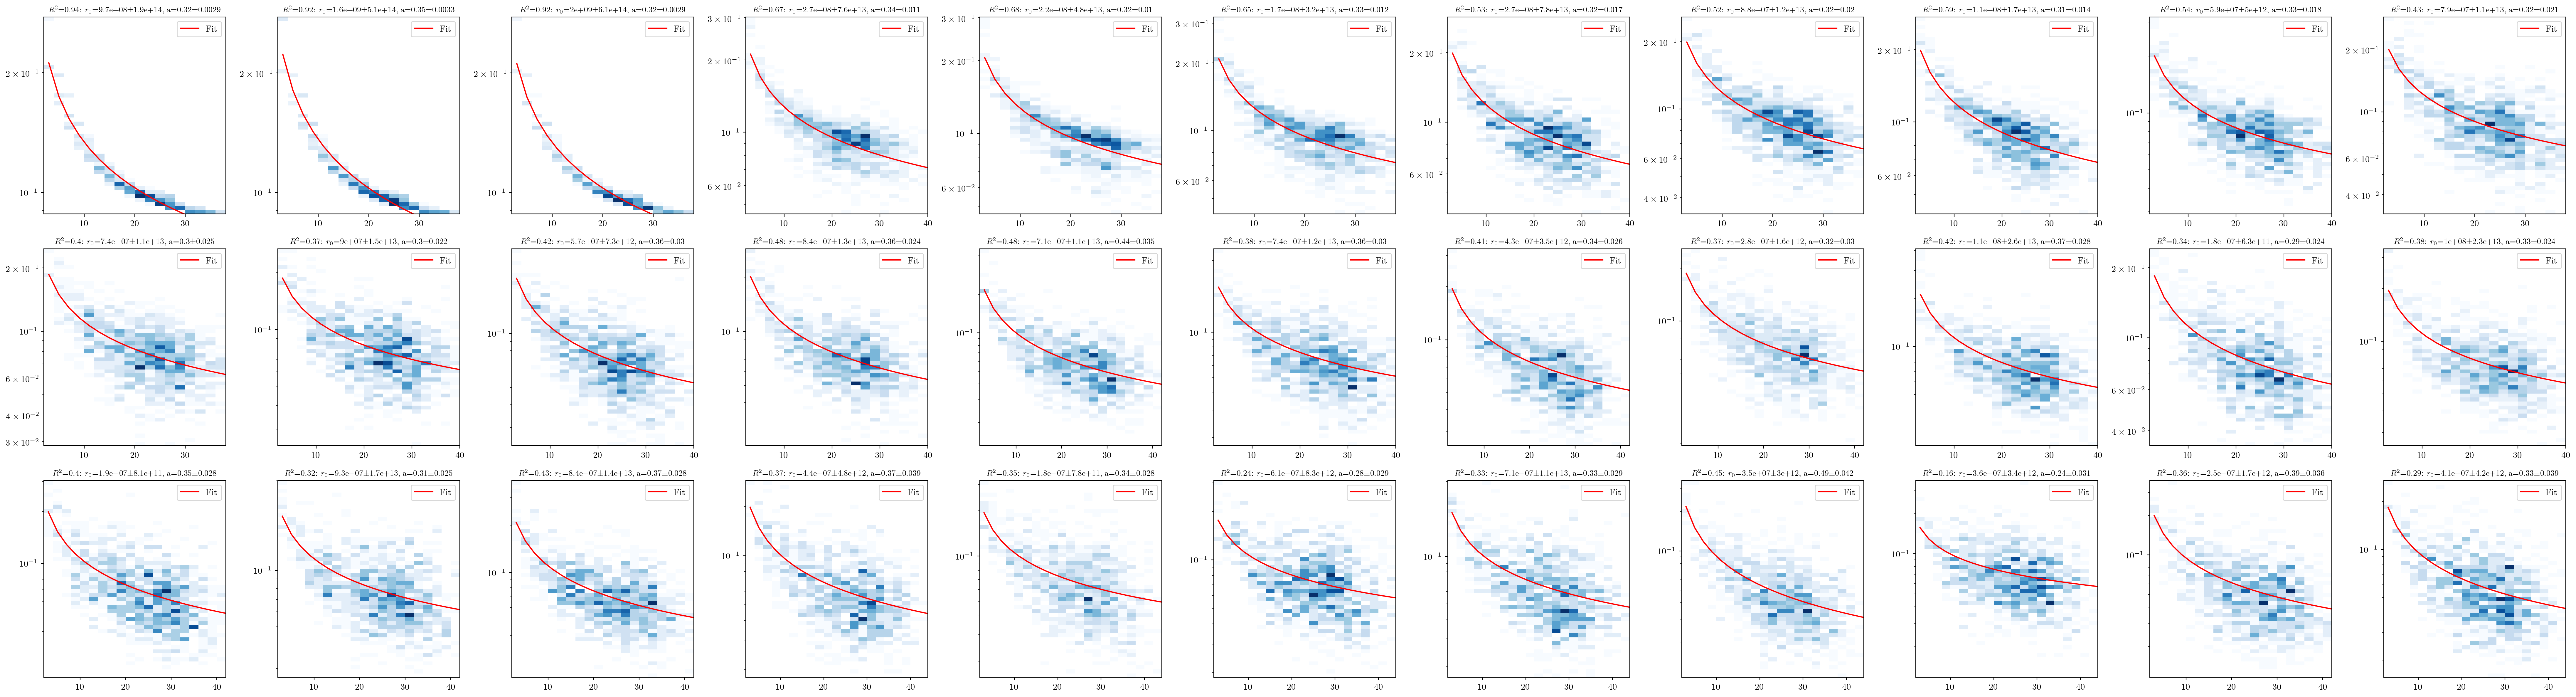

In [6]:
# curve fitting
from scipy.optimize import curve_fit


def fit_func(x, r0, a, pow):
    return a * np.exp(-x / r0) / x**pow


fig, ax = plt.subplots(
    3, len(all_results) // 3, figsize=np.array([len(all_results) // 3, 3]) * 4, dpi=200
)
ax = ax.flatten()
r0_values = []
r_0_errors = []

for j, r in enumerate(all_results):
    lat = r["lattice"]

    n = [p.n_sides for p in lat.plaquettes]
    # print(np.mean(n))

    # Fit the data
    popt, pcov = curve_fit(fit_func, r["distances"], r["probability"], p0=[5, 1, 0.5])

    # Plot the fit
    ax[j].plot(
        r["dist_unique"], fit_func(r["dist_unique"], *popt), label="Fit", color="red"
    )

    x_space = np.arange(np.min(r["distances"]), np.max(r["distances"] + 1))[::2]
    y_space = np.logspace(
        np.log10(np.min(r["probability"])),
        np.log10(np.max(r["probability"])),
        num=50,
    )
    ax[j].hist2d(
        r["distances"],
        r["probability"],
        bins=(x_space - 1, y_space),
        cmap="Blues",
        cmin=1,
    )
    # ax[j].plot(r["dist_unique"], r["mean"], label="Mean", color="black")

    #  find r squared value
    residuals = r["probability"] - fit_func(r["distances"], *popt)
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((r["probability"] - np.mean(r["probability"])) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    ax[j].set_title(
        f"$R^2$={r_squared:2.2g}: $r_0$={popt[0]:2.2g}±{np.sqrt(pcov[0, 0]):2.2g}, a={popt[1]:2.2g}±{np.sqrt(pcov[1, 1]):2.2g}",
        fontsize=10,
    )

    ax[j].set_yscale("log")

    r0_values.append(popt[0])
    r_0_errors.append(np.sqrt(pcov[0, 0]))

    # legend
    ax[j].legend()

plt.savefig("reducing_squares_2.png", dpi=300)
plt.tight_layout()
plt.show()

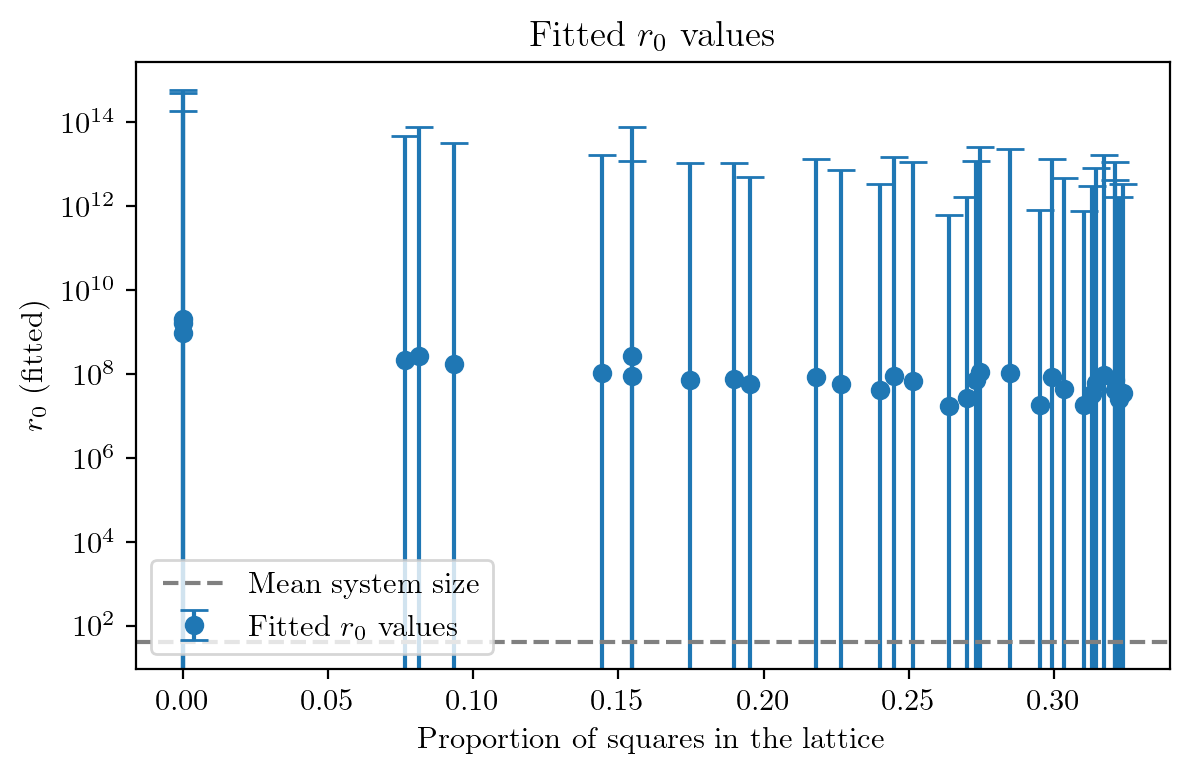

In [7]:
# plot r0 values
fig, ax = plt.subplots(figsize=(6, 4), dpi=200)
lattice_sizes = [r["lattice"].n_vertices for r in all_results]

psquare = []
l_distances = []

for r in all_results:
    l = r["lattice"]
    prop_squares = len([p for p in l.plaquettes if p.n_sides == 4]) / len(l.plaquettes)
    psquare.append(prop_squares)

    longest_distance = max(r["distances"])
    l_distances.append(longest_distance)


ax.errorbar(
    psquare,
    r0_values,
    yerr=r_0_errors,
    fmt="o",
    capsize=5,
    label="Fitted $r_0$ values",
)

ax.axhline(np.mean(l_distances), color="gray", linestyle="--", label="Mean system size")

ax.set_xlabel("Proportion of squares in the lattice")
ax.set_ylabel("$r_0$ (fitted)")
# ax.set_yscale("log")
# ax.set_ylim(0, 4000)

plt.legend()

ax.set_title(f"Fitted $r_0$ values")
plt.tight_layout()
ax.set_yscale("log")
lattice_sizes
plt.savefig("reducing_squares_3.png", dpi=300)

0.6326258166051274 0.09818945362889568


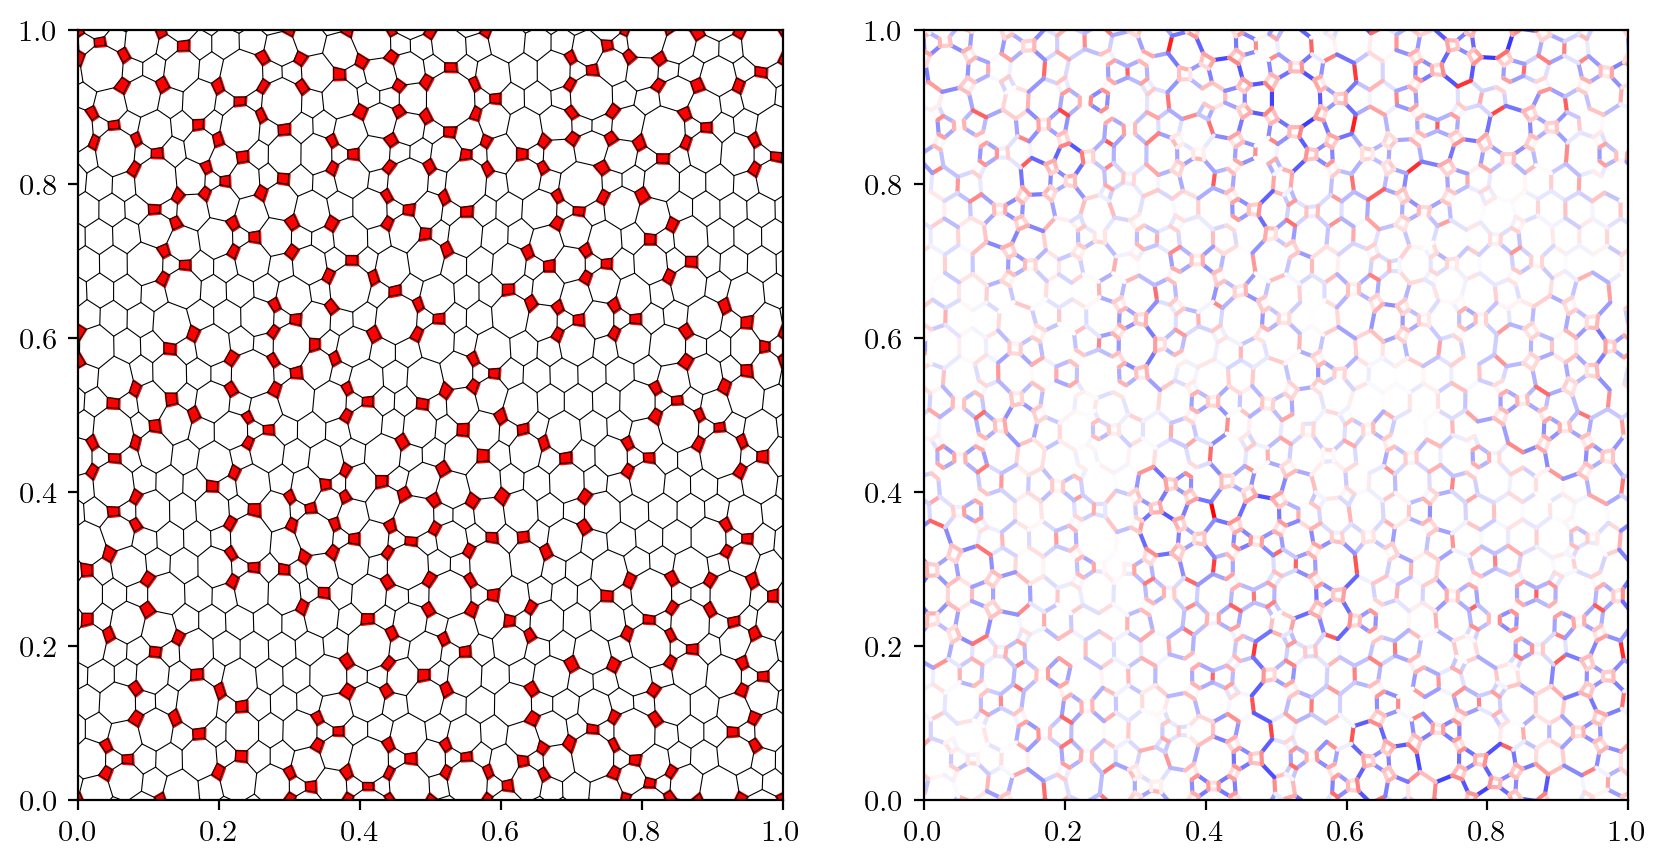

In [50]:
res = all_results[-1]

lat = gu.com_relaxation(res["lattice"])
n_sides = np.array([p.n_sides for p in lat.plaquettes])

fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=200)
# pl.plot_edges(gu.com_relaxation(lat), linewidth=0.4)
pl.plot_edges(lat, linewidth=0.4, ax=ax[0])
pl.plot_plaquettes(lat, labels=(n_sides == 4), color_scheme=["w", "r", "g"], ax=ax[0])

probs_normalised = res["dim_probs"] - 1 / 3
probs_normalised = 0.5 * probs_normalised / np.max(np.abs(probs_normalised))
edge_labels = np.arange(lat.n_edges)
cmap = plt.get_cmap("bwr")
color_scheme = cmap(probs_normalised + 0.5)  # Shift to center around 0
pl.plot_edges(
    lat,
    ax=ax[1],
    labels=edge_labels,
    color_scheme=color_scheme,
)
print(max(res["dim_probs"]), min(res["dim_probs"]))

plt.show()

In [22]:
len(all_results)

33